In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import warnings

In [13]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# DATASET

In [14]:
reels = pd.read_csv("/kaggle/input/datasets/filippotenani/regression-data/reels_extracted.csv")
stories = pd.read_csv("/kaggle/input/datasets/filippotenani/regression-data/stories_extracted.csv")

cluster_info = pd.read_csv("/kaggle/input/datasets/filippotenani/creator-cluster-data/stories_creator_cluster.csv")

# REELS REGRESSION (TOTAL)

## DATA PREPARATION

We prepare the target, necessary features and encoding of categorical variables.

In [15]:
reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Brand name', 'Industry',
       'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia',
       'first_face_position_ratio', 'motion_level', 'saturation', 'luminance',
       'contrast', 'sharpness', 'color_complexity', 'cognitive_overload',
       'flashiness', 'tone_video_api', 'voice_speed_video_api',
       'activity_video_api', 'format_video_api', 'product_integration_api',
       'funnel_api', 'posizionamento_api', 'hook_score_api',
       'microkinetics_video_api', 'tone_caption_api', 'funnel_caption_api',
       'caption_length', 'PERC_REACHED', 'ENGAGE_RATE', 'COMM_PER_LIKE'],
      dtype='object')

In [16]:
# TARGET

# ENGAGE_RATE = (Likes + Comments) / Reach
# misura quanto il pubblico raggiunto ha interagito attivamente col contenuto
# lo trasformiamo in percentuale
reels["TARGET"] = reels["ENGAGE_RATE"] * 100

In [17]:
# FEATURES

# we keep only the features we can use in the model
# we also remove Creator name and Brand name because they are categorical with too many categories
# in case we can use one later at the lasso stage as grouping variable for linear mixed model
features = [
    'Creator_gender', 'Followers', 'Type of content',
    'mese', 'Weekend/Settimanale', 'fascia_oraria', 
    'Industry', 'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio',
    'faccia', 'first_face_position_ratio', 'motion_level', 'saturation',
    'luminance', 'contrast', 'sharpness', 'color_complexity', 'tone_video_api',
    'voice_speed_video_api', 'activity_video_api', 'format_video_api',
    'product_integration_api', 'funnel_api', 'posizionamento_api', 'hook_score_api',
    'microkinetics_video_api', 'tone_caption_api', 'funnel_caption_api', 'caption_length'
]

In [18]:
# ENCODING

# ORDINALI
# mappiamo a interi che rispettano l'ordine naturale delle categorie

# speech speed
# 'lenta' collassata su 'normale' (1 sola osservazione)
reels['voice_speed_video_api'] = reels['voice_speed_video_api'].map({
    'assente': 0, 'lenta': 1, 'normale': 1, 'veloce': 2
})

# hook strength
reels['hook_score_api'] = reels['hook_score_api'].map({
    'weak': 0, 'medium': 1, 'strong': 2
})

# posizionamento brand
# 'non identificabile' collassato su 'accessibile' (moda)
reels['posizionamento_api'] = reels['posizionamento_api'].map({
    'non identificabile': 0, 'accessibile': 0, 'premium': 1, 'lusso': 2
})

# BINARIE
reels['Weekend/Settimanale'] = reels['Weekend/Settimanale'].map({'settimanale': 0, 'weekend': 1})
reels['Type of content']     = reels['Type of content'].map({'INSTAGRAM_REEL': 0, 'TIKTOK_POST': 1})

# NOMINALI
# one hot encoding
cols_ohe = [
    'tone_video_api', 'activity_video_api', 'format_video_api',
    'microkinetics_video_api', 'tone_caption_api',
    'Creator_gender', 'mese', 'fascia_oraria', 'Industry',
    'funnel_api', 'funnel_caption_api', 'product_integration_api'
]
reels = pd.get_dummies(reels, columns=cols_ohe, dtype=int)

# aggiorniamo features con le colonne ohe espanse
ohe_expanded = [c for c in reels.columns if any(c.startswith(col + "_") for col in cols_ohe)]
features_final = (
    [f for f in features if f not in cols_ohe] + ohe_expanded
)

data = reels[["TARGET", "Creator name"] + features_final].copy()

## LASSO FEATURE SELECTION

Since we have many variables, we run Lasso for initial feature selection.

In [19]:
# LASSO

# features e target
X = data[features_final]
y = np.log(data["TARGET"] + 0.001)

# standardizziamo per dare a lasso scala omogenea tra le feature
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# alpha=0.05: low penalty otherwise it removes too many variables
lasso = Lasso(alpha=0.05, max_iter=20000, random_state=42)
lasso.fit(X_scaled, y)

# variabili sopravvissute dalla lasso (coefficiente non zero)
coefs = pd.Series(lasso.coef_, index=X.columns)
sopravviss = coefs[coefs != 0].index.tolist()
print("Variabili selezionate:", len(sopravviss), "su", len(X.columns))
print(sopravviss)

Variabili selezionate: 43 su 79
['Followers', 'Type of content', 'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia', 'first_face_position_ratio', 'saturation', 'sharpness', 'color_complexity', 'voice_speed_video_api', 'hook_score_api', 'tone_video_api_neutro/assente', 'activity_video_api_né parlato né attività', 'activity_video_api_parlato con attività', 'format_video_api_basic placement', 'format_video_api_product review', 'microkinetics_video_api_assente', 'microkinetics_video_api_authoritative_expert', 'microkinetics_video_api_soft_engager', 'tone_caption_api_ironico/scherzoso', 'tone_caption_api_neutro/assente', 'Creator_gender_m', 'Creator_gender_o', 'mese_agosto', 'mese_aprile', 'mese_dicembre', 'mese_gennaio', 'mese_giugno', 'mese_maggio', 'mese_marzo', 'mese_ottobre', 'mese_settembre', 'fascia_oraria_cena', 'fascia_oraria_mattina', 'fascia_oraria_pomeriggio', 'Industry_Durables', 'Industry_Health', 'Industry_Lifestyle', 'funnel_api_consideration', 'funnel_c

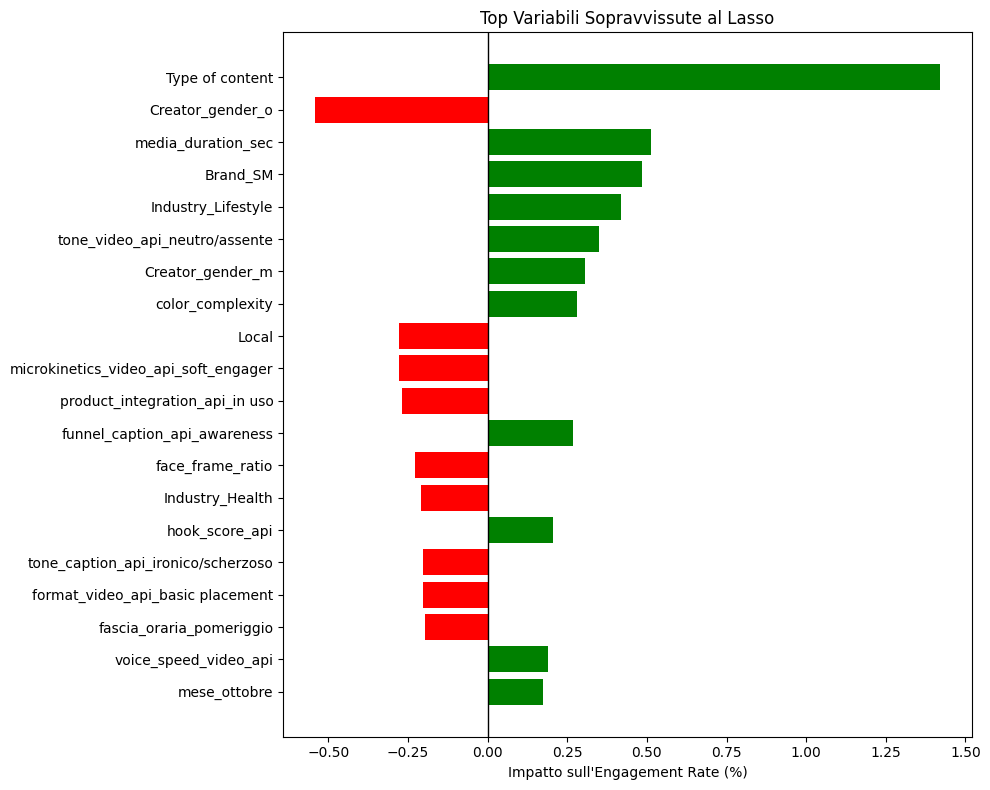

In [20]:
# GRAFICO VARIABILI SOPRAVVISSUTE

# prendiamo i coefficienti delle sopravvissute e ordiniamo per valore assoluto
survivors = (
    coefs[coefs != 0]
    .reset_index()
)
survivors.columns = ['Feature', 'Coefficiente']
survivors = survivors.reindex(survivors['Coefficiente'].abs().sort_values(ascending=False).index)

# let's visualize the top 20 variables that survived the lasso
top = survivors.head(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top['Feature'][::-1],
    top['Coefficiente'][::-1],
    color=['green' if x > 0 else 'red' for x in top['Coefficiente'][::-1]]
)
plt.xlabel("Impatto sull'Engagement Rate (%)")
plt.title("Top Variabili Sopravvissute al Lasso")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## REGRESSION MODEL

After various attempts, the best model turns out to be an OLS that links the posts of the same creator in time series by adding lag variables, i.e. using the target of the previous post as a covariate. Fitting AR1 with this limited amount of data causes convergence issues, so we decided to use the lag to represent temporal dependence.

In [21]:
# LAG AR(1)
# engagement rate del reel precedente per ogni creator
# cattura se un reel che ha performato bene trascina in alto il successivo

# per ogni creator prendiamo il valore di engagement del post precedente ordinato per data
df_time = reels[["Creator name", "Post creation date", "Post creation time", "TARGET"]].copy()
df_time["datetime"] = pd.to_datetime(
    df_time["Post creation date"] + " " + df_time["Post creation time"]
)
df_time = df_time.sort_values(["Creator name", "datetime"])
df_time["TARGET_LOG"] = np.log(df_time["TARGET"] + 0.001)
df_time["LAG_ENGAGE"] = df_time.groupby("Creator name")["TARGET_LOG"].shift(1)

# primo post di ogni creator non ha lag: usiamo la media del creator
# se il creator ha un solo post, cade sul global_mean
global_mean = df_time["LAG_ENGAGE"].mean()
df_time["LAG_ENGAGE"] = (
    df_time.groupby("Creator name")["LAG_ENGAGE"]
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(global_mean)
)
lag_aligned = df_time.loc[data.index, "LAG_ENGAGE"].values

In [22]:
# DATASET FINALE
# trasformiamo TARGET in log(TARGET + epsilon) per correggere la distribuzione destra
# epsilon=0.001 per evitare log(0) su post con engagement nullo
y_log = np.log(data["TARGET"] + 0.001)

# uniamo variabili lasso, lag e target in un unico dataframe
df_model = X_scaled[sopravviss].copy()
df_model = sm.add_constant(df_model)
df_model["LAG_ENGAGE"]   = lag_aligned
df_model["TARGET_LOG"]   = y_log.values
df_model["CREATOR_NAME"] = data["Creator name"].values
df_model = df_model.dropna().reset_index(drop=True)

y_ar      = df_model["TARGET_LOG"]
groups_ar = df_model["CREATOR_NAME"]
X_ar      = df_model.drop(columns=["TARGET_LOG", "CREATOR_NAME"])

                            OLS Regression Results                            
Dep. Variable:             TARGET_LOG   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     271.8
Date:                Fri, 29 May 2026   Prob (F-statistic):          1.61e-274
Time:                        15:01:56   Log-Likelihood:                -1287.2
No. Observations:                 981   AIC:                             2664.
Df Residuals:                     936   BIC:                             2884.
Df Model:                          44                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

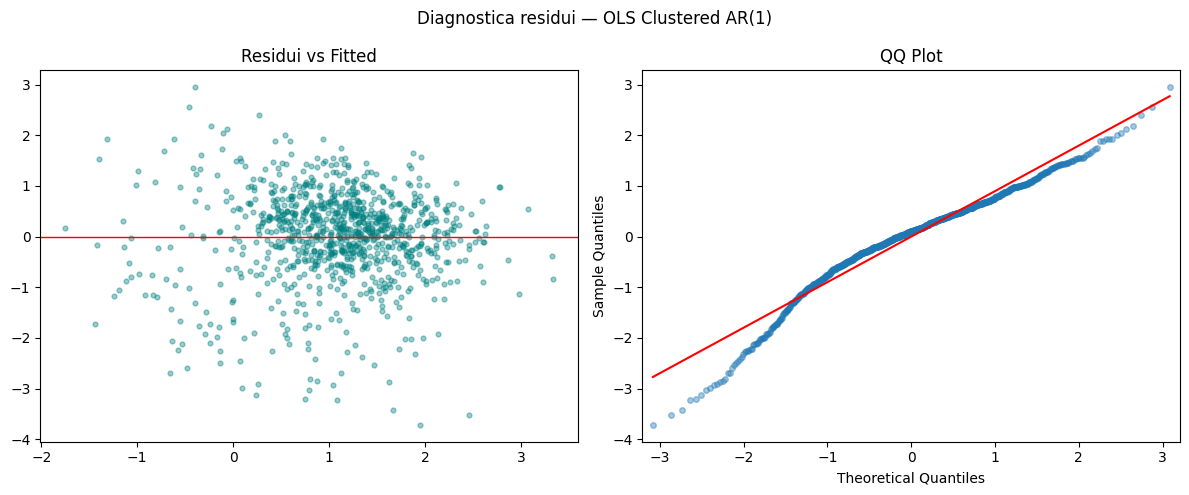

In [23]:
# MODELLO

# OLS con errori standard clusterizzati per creator
# corrects the correlation between posts of the same creator
results = sm.OLS(y_ar, X_ar).fit(cov_type="cluster", cov_kwds={"groups": groups_ar})
print(results.summary())

# diagnostica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Diagnostica residui — OLS Clustered AR(1)")

axes[0].scatter(results.fittedvalues, results.resid, alpha=0.4, s=12, color="teal")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residui vs Fitted")

sm.qqplot(results.resid, line="s", ax=axes[1], alpha=0.4, markersize=4)
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

# STORIES REGRESSION (TOTAL)

## DATA PREPARATION

We prepare the target, necessary features and encoding of categorical variables.

In [24]:
stories.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Total clicks', 'Brand name', 'Industry',
       'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia',
       'first_face_position_ratio', 'motion_level', 'saturation', 'luminance',
       'contrast', 'sharpness', 'color_complexity', 'cognitive_overload',
       'flashiness', 'tone_video_api', 'voice_speed_video_api',
       'activity_video_api', 'format_video_api', 'product_integration_api',
       'funnel_api', 'posizionamento_api', 'hook_score_api',
       'microkinetics_video_api', 'PERC_REACHED', 'CTR'],
      dtype='object')

In [25]:
# CLEANING

# in the hook variable there are 11 ERROR due to the LLM extraction
# li sostituiamo con la moda
print(stories["hook_score_api"].value_counts())
stories['hook_score_api'] = stories['hook_score_api'].replace(
    r'^ERROR.*', 'medium', regex=True
)

hook_score_api
medium                                     1059
weak                                        716
strong                                      396
ERROR: [Errno 11001] getaddrinfo failed      11
Name: count, dtype: int64


In [26]:
# TARGET

# CTR = (Total Clicks) / Reach
# misura quanto il pubblico raggiunto ha cliccato sul link sponsor del contenuto
# lo trasformiamo in percentuale
stories["TARGET"] = stories["CTR"] * 100

In [27]:
# FEATURES

# we keep only the features we can use in the model
# we also remove Creator name and Brand name because they are categorical with too many categories
# in case we can use one later at the lasso stage as grouping variable for linear mixed model
features = [
    'Creator_gender', 'Followers',
    'mese', 'Weekend/Settimanale', 'fascia_oraria', 
    'Industry', 'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio',
    'faccia', 'first_face_position_ratio', 'motion_level', 'saturation',
    'luminance', 'contrast', 'sharpness', 'color_complexity', 'tone_video_api',
    'voice_speed_video_api', 'activity_video_api', 'format_video_api',
    'product_integration_api', 'funnel_api', 'posizionamento_api', 'hook_score_api',
    'microkinetics_video_api'
]

In [28]:
# ENCODING

# ORDINALI
# mappiamo a interi che rispettano l'ordine naturale delle categorie

# speech speed
# 'lenta' non è presente
stories['voice_speed_video_api'] = stories['voice_speed_video_api'].map({
    'assente': 0, 'normale': 1, 'veloce': 2
})

# hook strength
stories['hook_score_api'] = stories['hook_score_api'].map({
    'weak': 0, 'medium': 1, 'strong': 2
})

# posizionamento brand
# 'non identificabile' collassato su 'accessibile' (moda)
stories['posizionamento_api'] = stories['posizionamento_api'].map({
    'non identificabile': 0, 'accessibile': 0, 'premium': 1, 'lusso': 2
})

# BINARIE
stories['Weekend/Settimanale'] = stories['Weekend/Settimanale'].map({'settimanale': 0, 'weekend': 1})

# NOMINALI
# one hot encoding
cols_ohe = [
    'tone_video_api', 'activity_video_api', 'format_video_api',
    'microkinetics_video_api',
    'Creator_gender', 'mese', 'fascia_oraria', 'Industry',
    'funnel_api', 'product_integration_api'
]
stories = pd.get_dummies(stories, columns=cols_ohe, dtype=int)

# aggiorniamo features con le colonne ohe espanse
ohe_expanded = [c for c in stories.columns if any(c.startswith(col + "_") for col in cols_ohe)]
features_final = (
    [f for f in features if f not in cols_ohe] + ohe_expanded
)

data = stories[["TARGET", "Creator name"] + features_final].copy()

## LASSO FEATURE SELECTION

Since we have many variables, we run Lasso for initial feature selection.

In [29]:
# LASSO

# features e target
X = data[features_final]
y = np.log(data["TARGET"] + 0.001)

# standardizziamo per dare a lasso scala omogenea tra le feature
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# alpha=0.05: low penalty otherwise it removes too many variables
lasso = Lasso(alpha=0.05, max_iter=20000, random_state=42)
lasso.fit(X_scaled, y)

# variabili sopravvissute dalla lasso (coefficiente non zero)
coefs = pd.Series(lasso.coef_, index=X.columns)
sopravviss = coefs[coefs != 0].index.tolist()
print("Variabili selezionate:", len(sopravviss), "su", len(X.columns))
print(sopravviss)

Variabili selezionate: 17 su 70
['Followers', 'Weekend/Settimanale', 'contrast', 'sharpness', 'tone_video_api_logico/informativo', 'format_video_api_basic placement', 'Creator_gender_m', 'mese_febbraio', 'mese_luglio', 'mese_maggio', 'mese_ottobre', 'mese_settembre', 'fascia_oraria_pomeriggio', 'Industry_Durables', 'Industry_Lifestyle', 'Industry_Retail', 'funnel_api_conversion']


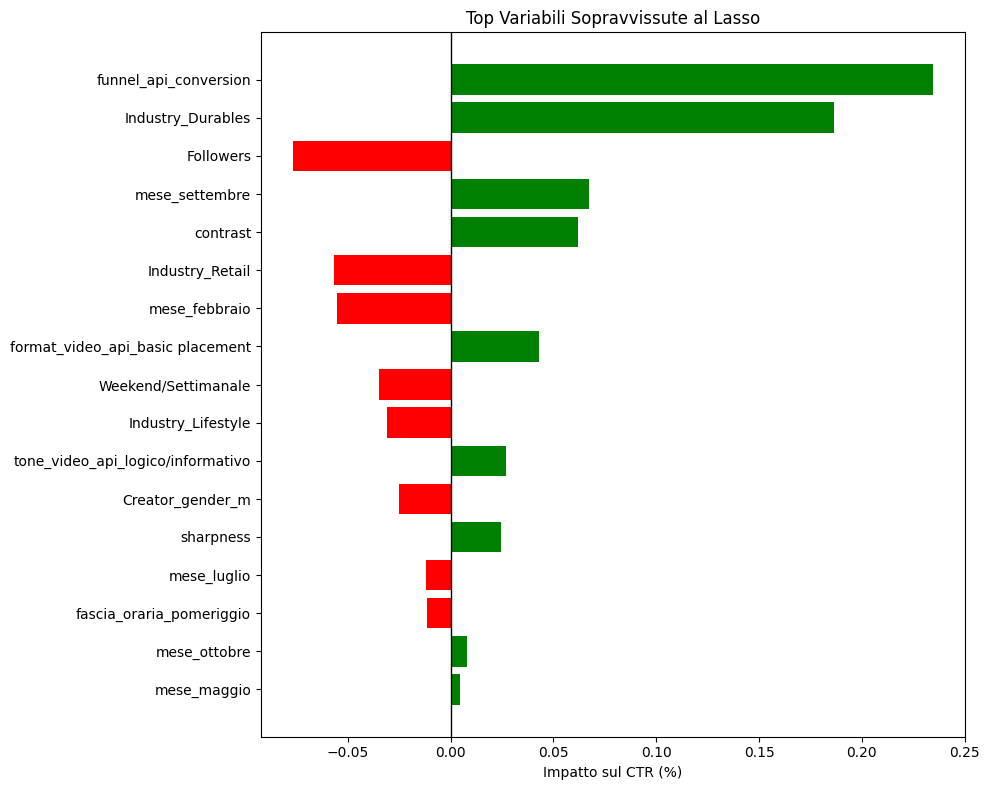

In [30]:
# GRAFICO VARIABILI SOPRAVVISSUTE

# prendiamo i coefficienti delle sopravvissute e ordiniamo per valore assoluto
survivors = (
    coefs[coefs != 0]
    .reset_index()
)
survivors.columns = ['Feature', 'Coefficiente']
survivors = survivors.reindex(survivors['Coefficiente'].abs().sort_values(ascending=False).index)

# let's visualize the top 20 variables that survived the lasso
top = survivors.head(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top['Feature'][::-1],
    top['Coefficiente'][::-1],
    color=['green' if x > 0 else 'red' for x in top['Coefficiente'][::-1]]
)
plt.xlabel("Impatto sul CTR (%)")
plt.title("Top Variabili Sopravvissute al Lasso")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## REGRESSION MODEL

After various attempts, the best model turns out to be an OLS that links the posts of the same creator in time series by adding lag variables, i.e. using the target of the previous post as a covariate. Fitting AR1 with this limited amount of data causes convergence issues, so we decided to use the lag to represent temporal dependence.

In [31]:
# LAG AR(1)
# CTR della story precedente per ogni creator
# cattura se una story che ha performato bene trascina in alto il successivo

# for each creator we take the CTR value of the previous story sorted by date
df_time = stories[["Creator name", "Post creation date", "Post creation time", "TARGET"]].copy()
df_time["datetime"] = pd.to_datetime(
    df_time["Post creation date"] + " " + df_time["Post creation time"]
)
df_time = df_time.sort_values(["Creator name", "datetime"])
df_time["TARGET_LOG"] = np.log(df_time["TARGET"] + 0.001)
df_time["LAG_CTR"] = df_time.groupby("Creator name")["TARGET_LOG"].shift(1)

# primo post di ogni creator non ha lag: usiamo la media del creator
# se il creator ha un solo post, cade sul global_mean
global_mean = df_time["LAG_CTR"].mean()
df_time["LAG_CTR"] = (
    df_time.groupby("Creator name")["LAG_CTR"]
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(global_mean)
)
lag_aligned = df_time.loc[data.index, "LAG_CTR"].values

In [32]:
# DATASET FINALE
# trasformiamo TARGET in log(TARGET + epsilon) per correggere la distribuzione destra
# epsilon=0.001 per evitare log(0) su post con CTR nullo
y_log = np.log(data["TARGET"] + 0.001)

# uniamo variabili lasso, lag e target in un unico dataframe
df_model = X_scaled[sopravviss].copy()
df_model = sm.add_constant(df_model)
df_model["LAG_CTR"]   = lag_aligned
df_model["TARGET_LOG"]   = y_log.values
df_model["CREATOR_NAME"] = data["Creator name"].values
df_model = df_model.dropna().reset_index(drop=True)

y_ar      = df_model["TARGET_LOG"]
groups_ar = df_model["CREATOR_NAME"]
X_ar      = df_model.drop(columns=["TARGET_LOG", "CREATOR_NAME"])

                            OLS Regression Results                            
Dep. Variable:             TARGET_LOG   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     49.09
Date:                Fri, 29 May 2026   Prob (F-statistic):           9.19e-94
Time:                        15:01:57   Log-Likelihood:                -3510.7
No. Observations:                2182   AIC:                             7059.
Df Residuals:                    2163   BIC:                             7167.
Df Model:                          18                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

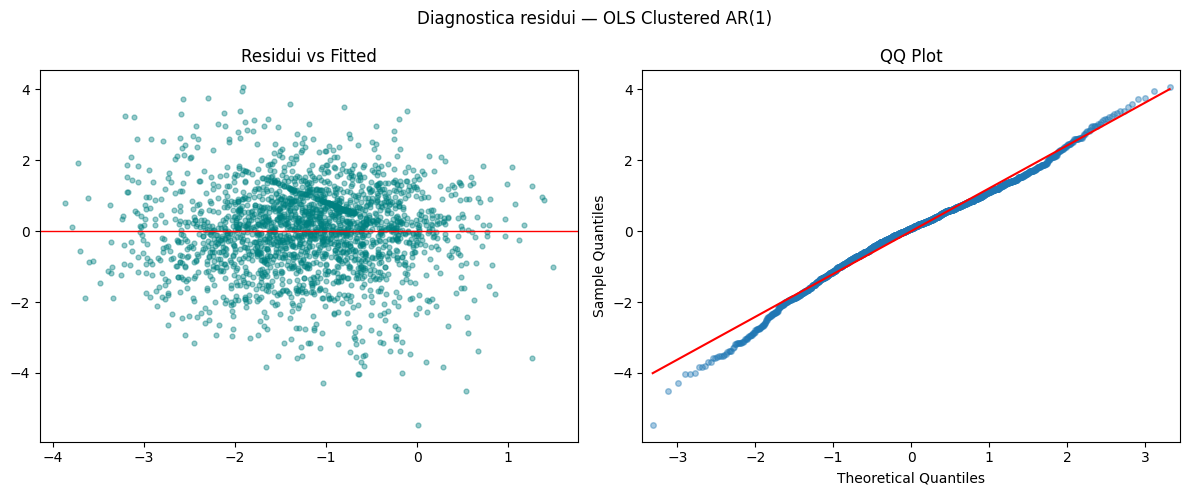

In [33]:
# MODELLO

# OLS con errori standard clusterizzati per creator
# corrects the correlation between posts of the same creator
results = sm.OLS(y_ar, X_ar).fit(cov_type="cluster", cov_kwds={"groups": groups_ar})
print(results.summary())

# diagnostica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Diagnostica residui — OLS Clustered AR(1)")

axes[0].scatter(results.fittedvalues, results.resid, alpha=0.4, s=12, color="teal")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residui vs Fitted")

sm.qqplot(results.resid, line="s", ax=axes[1], alpha=0.4, markersize=4)
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

# STORIES REGRESSION (BY CLUSTER)

During clustering (done in a previous notebook) we identified three clusters of creators: Macro, Mid-Size, Micro. It could be interesting, after running the regression on the total dataset, to also run one per cluster to see if for creators of different sizes, different variables impact CTR.

Unfortunately from clustering it emerged that Mid-Size creators (who by the way are those with the clearly highest CTR) have a total of 68 posts (spread across 18 creators), obviously too few to run a regression on them, but we can still do it for Macro and Micro.

In [34]:
# merge delle informazioni cluster sul dataset già encodato
data = data.merge(cluster_info[["Creator name", "cluster_name"]], on="Creator name", how="left")
print(data["cluster_name"].value_counts())

# split in creator Macro e Micro
# Mid-Size  18 creator 868 post in totale), troppo pochi, scartato
data_macro = data[data["cluster_name"] == "Macro"].copy()
data_micro = data[data["cluster_name"] == "Micro"].copy()

print("done")

cluster_name
Macro       1200
Micro        914
Mid-Size      68
Name: count, dtype: int64
done


## LASSO (MICRO)

In [35]:
# LASSO

# features e target
X = data_micro[features_final]
y = np.log(data_micro["TARGET"] + 0.001)

# standardizziamo per dare a lasso scala omogenea tra le feature
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# alpha=0.05: low penalty otherwise it removes too many variables
lasso = Lasso(alpha=0.05, max_iter=20000, random_state=42)
lasso.fit(X_scaled, y)

# variabili sopravvissute dalla lasso (coefficiente non zero)
coefs = pd.Series(lasso.coef_, index=X.columns)
sopravviss = coefs[coefs != 0].index.tolist()
print("Variabili selezionate:", len(sopravviss), "su", len(X.columns))
print(sopravviss)

Variabili selezionate: 10 su 70
['motion_level', 'contrast', 'format_video_api_basic placement', 'mese_luglio', 'Industry_Durables', 'Industry_Food', 'Industry_Lifestyle', 'Industry_Retail', 'funnel_api_consideration', 'funnel_api_conversion']


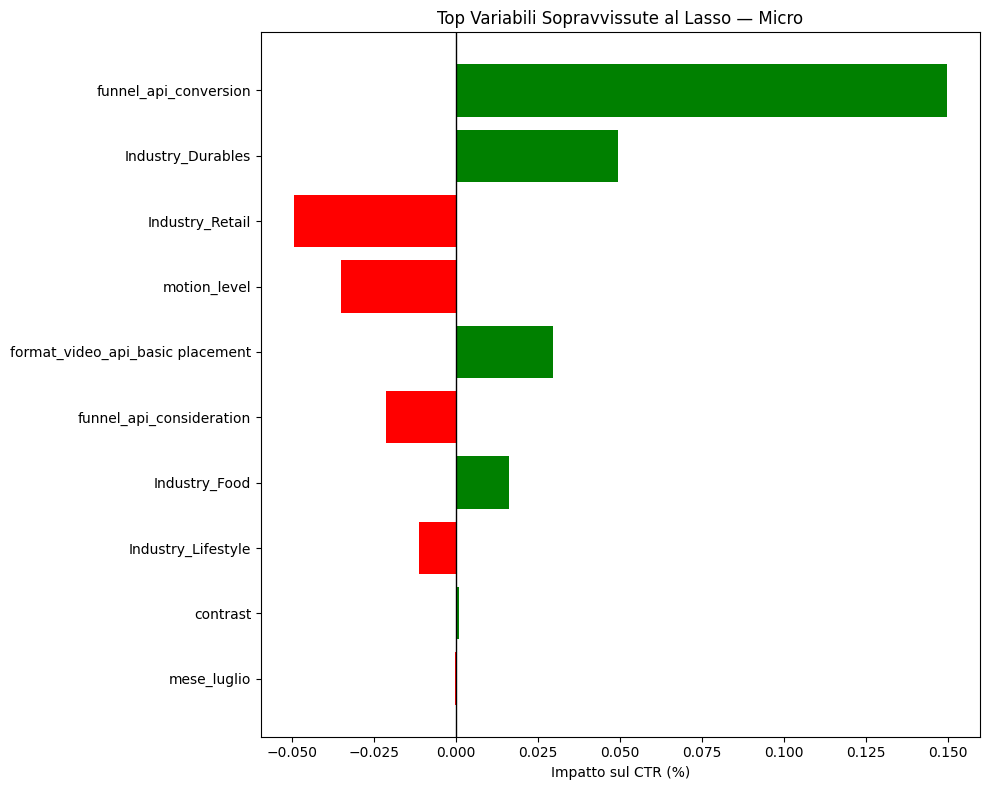

In [36]:
# GRAFICO VARIABILI SOPRAVVISSUTE

# prendiamo i coefficienti delle sopravvissute e ordiniamo per valore assoluto
survivors = (
    coefs[coefs != 0]
    .reset_index()
)
survivors.columns = ['Feature', 'Coefficiente']
survivors = survivors.reindex(survivors['Coefficiente'].abs().sort_values(ascending=False).index)

# let's visualize the top 20 variables that survived the lasso
top = survivors.head(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top['Feature'][::-1],
    top['Coefficiente'][::-1],
    color=['green' if x > 0 else 'red' for x in top['Coefficiente'][::-1]]
)
plt.xlabel("Impatto sul CTR (%)")
plt.title("Top Variabili Sopravvissute al Lasso — Micro")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## REGRESSION MODEL (MICRO)

In [37]:
# LAG AR(1)
# CTR della story precedente per ogni creator
# cattura se una story che ha performato bene trascina in alto il successivo

# for each creator we take the CTR value of the previous story sorted by date
df_time = stories[["Creator name", "Post creation date", "Post creation time", "TARGET"]].copy()
df_time["datetime"] = pd.to_datetime(
    df_time["Post creation date"] + " " + df_time["Post creation time"]
)
df_time = df_time.sort_values(["Creator name", "datetime"])
df_time["TARGET_LOG"] = np.log(df_time["TARGET"] + 0.001)
df_time["LAG_CTR"] = df_time.groupby("Creator name")["TARGET_LOG"].shift(1)

# primo post di ogni creator non ha lag: usiamo la media del creator
# se il creator ha un solo post, cade sul global_mean
global_mean = df_time[df_time["Creator name"].isin(data_micro["Creator name"].unique())]["LAG_CTR"].mean()
df_time["LAG_CTR"] = (
    df_time.groupby("Creator name")["LAG_CTR"]
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(global_mean)
)
lag_aligned = df_time.loc[data_micro.index, "LAG_CTR"].values

In [38]:
# DATASET FINALE
# trasformiamo TARGET in log(TARGET + epsilon) per correggere la distribuzione destra
# epsilon=0.001 per evitare log(0) su post con CTR nullo
y_log = np.log(data_micro["TARGET"] + 0.001)

# uniamo variabili lasso, lag e target in un unico dataframe
df_model = X_scaled[sopravviss].copy()
df_model = sm.add_constant(df_model)
df_model["LAG_CTR"]   = lag_aligned
df_model["TARGET_LOG"]   = y_log.values
df_model["CREATOR_NAME"] = data_micro["Creator name"].values
df_model = df_model.dropna().reset_index(drop=True)

y_ar      = df_model["TARGET_LOG"]
groups_ar = df_model["CREATOR_NAME"]
X_ar      = df_model.drop(columns=["TARGET_LOG", "CREATOR_NAME"])

                            OLS Regression Results                            
Dep. Variable:             TARGET_LOG   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     32.87
Date:                Fri, 29 May 2026   Prob (F-statistic):           5.42e-40
Time:                        15:01:58   Log-Likelihood:                -1300.3
No. Observations:                 914   AIC:                             2625.
Df Residuals:                     902   BIC:                             2682.
Df Model:                          11                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

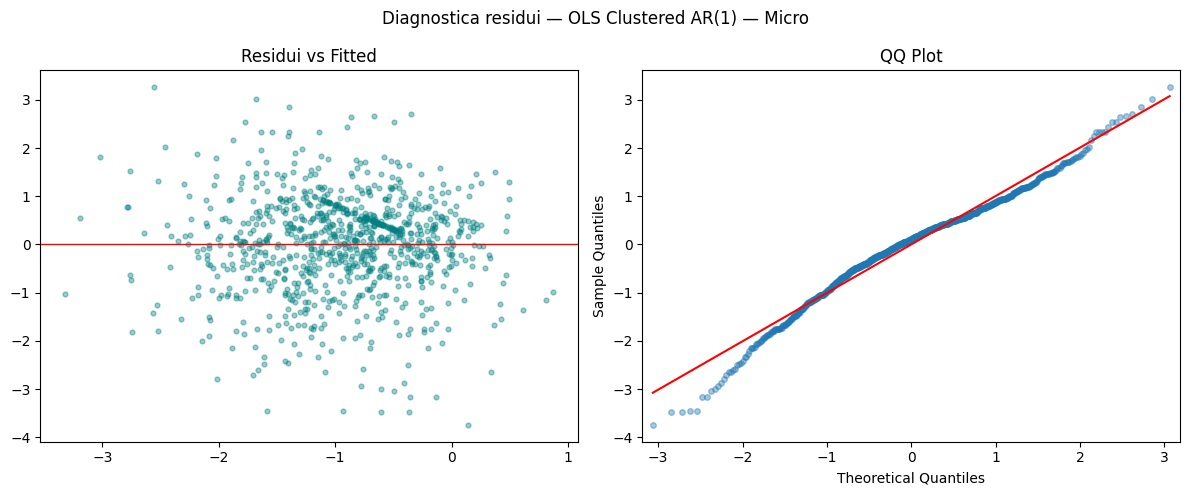

In [39]:
# MODELLO

# OLS con errori standard clusterizzati per creator
# corrects the correlation between posts of the same creator
results = sm.OLS(y_ar, X_ar).fit(cov_type="cluster", cov_kwds={"groups": groups_ar})
print(results.summary())

# diagnostica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Diagnostica residui — OLS Clustered AR(1) — Micro")

axes[0].scatter(results.fittedvalues, results.resid, alpha=0.4, s=12, color="teal")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residui vs Fitted")

sm.qqplot(results.resid, line="s", ax=axes[1], alpha=0.4, markersize=4)
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

## LASSO (MACRO)

In [40]:
# LASSO

# features e target
X = data_macro[features_final]
y = np.log(data_macro["TARGET"] + 0.001)

# standardizziamo per dare a lasso scala omogenea tra le feature
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# alpha=0.05: low penalty otherwise it removes too many variables
lasso = Lasso(alpha=0.05, max_iter=20000, random_state=42)
lasso.fit(X_scaled, y)

# variabili sopravvissute dalla lasso (coefficiente non zero)
coefs = pd.Series(lasso.coef_, index=X.columns)
sopravviss = coefs[coefs != 0].index.tolist()
print("Variabili selezionate:", len(sopravviss), "su", len(X.columns))
print(sopravviss)

Variabili selezionate: 23 su 70
['Followers', 'Local', 'faccia', 'saturation', 'contrast', 'sharpness', 'color_complexity', 'voice_speed_video_api', 'tone_video_api_logico/informativo', 'format_video_api_basic placement', 'microkinetics_video_api_soft_engager', 'Creator_gender_m', 'mese_febbraio', 'mese_maggio', 'mese_ottobre', 'mese_settembre', 'fascia_oraria_pomeriggio', 'fascia_oraria_pranzo', 'Industry_Durables', 'Industry_Lifestyle', 'Industry_Retail', 'funnel_api_consideration', 'funnel_api_conversion']


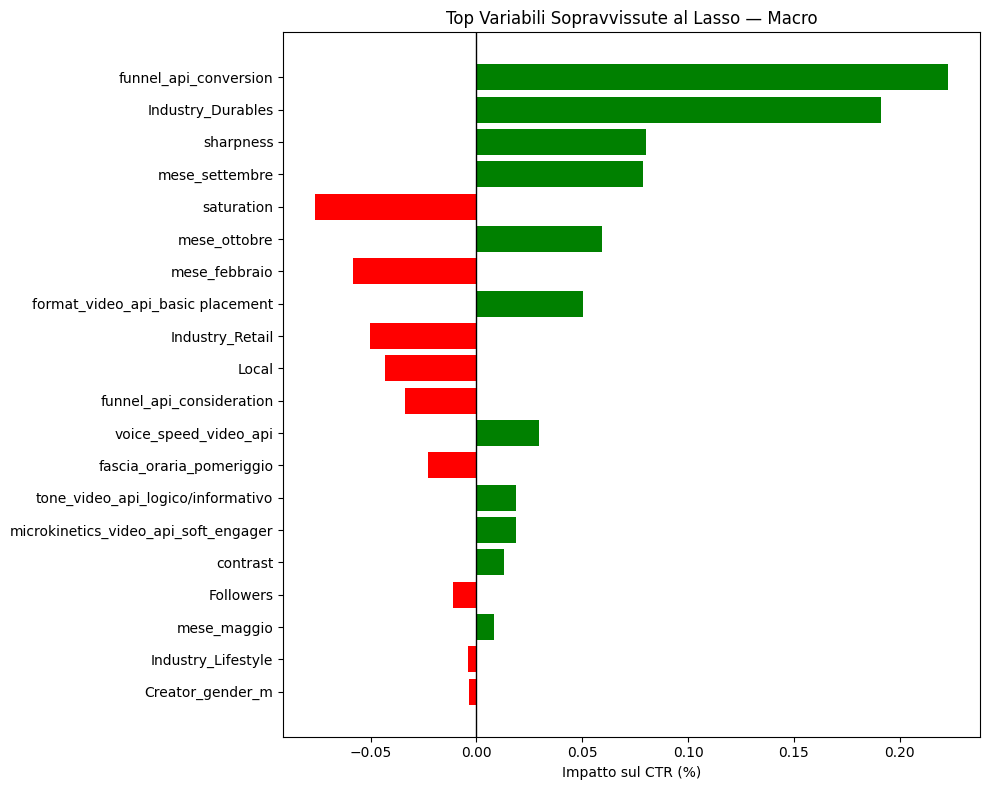

In [41]:
# GRAFICO VARIABILI SOPRAVVISSUTE

# prendiamo i coefficienti delle sopravvissute e ordiniamo per valore assoluto
survivors = (
    coefs[coefs != 0]
    .reset_index()
)
survivors.columns = ['Feature', 'Coefficiente']
survivors = survivors.reindex(survivors['Coefficiente'].abs().sort_values(ascending=False).index)

# let's visualize the top 20 variables that survived the lasso
top = survivors.head(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top['Feature'][::-1],
    top['Coefficiente'][::-1],
    color=['green' if x > 0 else 'red' for x in top['Coefficiente'][::-1]]
)
plt.xlabel("Impatto sul CTR (%)")
plt.title("Top Variabili Sopravvissute al Lasso — Macro")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## REGRESSION MODEL (MACRO)

In [42]:
# LAG AR(1)
# CTR della story precedente per ogni creator
# cattura se una story che ha performato bene trascina in alto il successivo

# for each creator we take the CTR value of the previous story sorted by date
df_time = stories[["Creator name", "Post creation date", "Post creation time", "TARGET"]].copy()
df_time["datetime"] = pd.to_datetime(
    df_time["Post creation date"] + " " + df_time["Post creation time"]
)
df_time = df_time.sort_values(["Creator name", "datetime"])
df_time["TARGET_LOG"] = np.log(df_time["TARGET"] + 0.001)
df_time["LAG_CTR"] = df_time.groupby("Creator name")["TARGET_LOG"].shift(1)

# primo post di ogni creator non ha lag: usiamo la media del creator
# se il creator ha un solo post, cade sul global_mean
global_mean = df_time[df_time["Creator name"].isin(data_macro["Creator name"].unique())]["LAG_CTR"].mean()
df_time["LAG_CTR"] = (
    df_time.groupby("Creator name")["LAG_CTR"]
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(global_mean)
)
lag_aligned = df_time.loc[data_macro.index, "LAG_CTR"].values

In [43]:
# DATASET FINALE
# trasformiamo TARGET in log(TARGET + epsilon) per correggere la distribuzione destra
# epsilon=0.001 per evitare log(0) su post con CTR nullo
y_log = np.log(data_macro["TARGET"] + 0.001)

# uniamo variabili lasso, lag e target in un unico dataframe
df_model = X_scaled[sopravviss].copy()
df_model = sm.add_constant(df_model)
df_model["LAG_CTR"]   = lag_aligned
df_model["TARGET_LOG"]   = y_log.values
df_model["CREATOR_NAME"] = data_macro["Creator name"].values
df_model = df_model.dropna().reset_index(drop=True)

y_ar      = df_model["TARGET_LOG"]
groups_ar = df_model["CREATOR_NAME"]
X_ar      = df_model.drop(columns=["TARGET_LOG", "CREATOR_NAME"])

                            OLS Regression Results                            
Dep. Variable:             TARGET_LOG   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     23.94
Date:                Fri, 29 May 2026   Prob (F-statistic):           4.61e-48
Time:                        15:01:59   Log-Likelihood:                -2006.5
No. Observations:                1200   AIC:                             4063.
Df Residuals:                    1175   BIC:                             4190.
Df Model:                          24                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


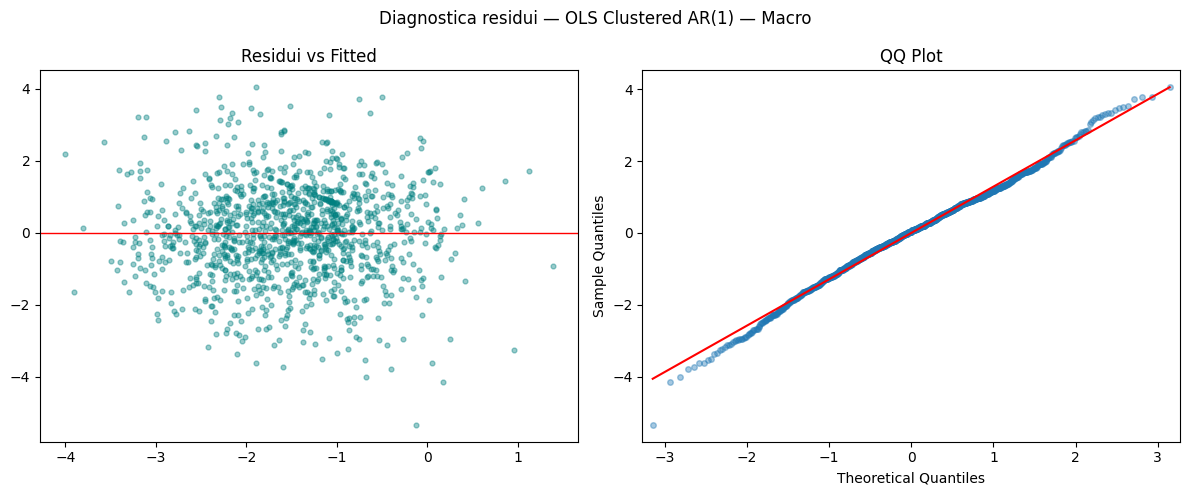

In [44]:
# MODELLO

# OLS con errori standard clusterizzati per creator
# corrects the correlation between posts of the same creator
results = sm.OLS(y_ar, X_ar).fit(cov_type="cluster", cov_kwds={"groups": groups_ar})
print(results.summary())

# diagnostica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Diagnostica residui — OLS Clustered AR(1) — Macro")

axes[0].scatter(results.fittedvalues, results.resid, alpha=0.4, s=12, color="teal")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residui vs Fitted")

sm.qqplot(results.resid, line="s", ax=axes[1], alpha=0.4, markersize=4)
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

# MODEL COMPARISON

### 1. The pattern that dominates everywhere: persistence (LAG)
In all four models the strongest variable by far is the value of the previous post by the same
creator: Reels +0.51, Stories total +0.44, Micro +0.38, Macro +0.34 (all p<0.001).
Engagement and CTR are "sticky" per creator: those who performed well last time tend to do it again.
The effect is more marked on Reels (engagement) than on Stories (CTR) and decreases going from Micro to Macro,
a sign that small creators are more "dragged along" by their recent history, the big ones more stable.

MESSAGE: the strongest predictor in every model is the performance of the previous post by the same creator. It means that the number one lever is not the single piece of content but the choice of creator: those who are in a good moment tend to confirm it. It holds especially for Micro, more dragged along by their recent wake, while Macro are more stable and predictable - the former should be taken when they are "pulling", the latter give a constant value to plan on.

### 2. Reels: what drives ENGAGEMENT
Besides the lag, the main significant drivers:
- Type of content +0.28: TikTok posts have clearly higher engagement than Instagram Reel. It is the
  largest controllable factor in the model.
- Industry: Lifestyle +0.14 and Durables +0.11 push it up, Health -0.12 down.
- Visual "rich": color_complexity +0.12 and saturation +0.10 increase engagement; average duration +0.09
  means that slightly longer videos perform better.
- Hook: hook_score +0.07 (p=0.015), a strong hook really helps engagement (but, as we will see, NOT the CTR).
- Negative effects: Local -0.13 (local brands lower engagement), product_integration "in uso" -0.09
  (showing the product in use lowers engagement), face_frame_ratio -0.08 (more face on screen brings
  less engagement), format "basic placement" -0.09, caption ironico/scherzoso -0.07, afternoon -0.07.

MESSAGE: engagement rewards content that people enjoy watching. Pushing it up are the Type of content (TikTok more than Instagram Reel), a loaded visual (color_complexity, saturation), a slightly longer duration and a strong hook. Holding it back instead are the "spot"-like signals: product_integration with product in uso, too much face on screen (face_frame_ratio), format basic placement and ironic caption tone. The operational direction is less product showcase and more content that entertains, avoiding the afternoon slot.

### 3. Stories total: what drives the CTR
Besides the lag, the picture is different from the Reels:
- funnel_api_conversion +0.34: by far the most powerful controllable lever. Stories with conversion
  intent generate many more clicks, consistently with the fact that the CTR measures the click, not the engagement.
- Followers -0.18: the larger the audience, the lower the CTR.
- Industry: Durables +0.11 positive; Retail -0.15 and Lifestyle -0.12 negative.
- Visual "clean": sharpness +0.07 and contrast +0.06 help the clicks, while saturation -0.06 reduces them,
  the opposite of the Reels.
- Format: "basic placement" +0.10 and product_integration "in scena" +0.07 help the CTR.
- Timing: evening slot +0.07 means that stories posted in the evening get more clicks.
- Negatives: tone video ironico/scherzoso -0.06, February -0.14, July -0.05.

MESSAGE: the story is the moment of action, not of entertainment. The click is driven above all by the conversion funnel, by a product well placed in the scene and by a clean and sharp visual (sharpness, contrast), the opposite of the saturation that helps the Reels, better if posted in the evening. Worth noting the sign of Followers: larger audiences click less, so for traffic objectives a small and targeted creator can yield more than a big name.

### 4. Micro vs Macro: the same clicks, different levers
In common (both clusters): funnel_conversion strongly positive (Micro +0.21, Macro +0.36),
sharpness positive, Industry_Retail negative, and a negative seasonality (September/February).
- Specific to Micro: voice_speed +0.10 (speaking faster helps the small ones), motion_level -0.09
  (excessive movement distracts), Creator_gender_m -0.08, and Lifestyle very negative (-0.21).
  product_integration "in scena" +0.11 is stronger than elsewhere.
- Specific to Macro: funnel_conversion is the dominant lever (+0.36), but its own brakes also appear:
  funnel_consideration -0.15, Local -0.13, tone ironico/scherzoso -0.12 (much more penalizing than in the Micro),
  format "brand experience/event" -0.09. Durables +0.11 remains positive. Followers here is NOT significant
  (the size-effect runs out within the cluster).

MESSAGE: conversion intent works for everyone, but the "how" changes with the size. On Micro what counts is proximity and direct energy: higher voice_speed, little motion_level, product in scena, basically a friend's-advice style. On Macro, instead, some elements get fewer clicks: stories of consideration only (without a clear push to action), local brands, ironic tone and the format "brand experience/event" all lower the CTR.  Small ones are asked for spontaneity and a direct call-to-action, big ones for sober messages oriented to conversion.

### 5. The "sign reversals" between engagement and CTR
Same variable, opposite effect depending on the objective:
- saturation: + on the Reels engagement, - on the Stories CTR. The saturated/vivid visual captures passive
  attention but does not push to the click.
- format "basic placement": - on the Reels engagement, + on the Stories CTR. The simple placement holds
  back the interaction but favors the click.
- hook_score: counts only for the engagement (Reels +), irrelevant/negative for the CTR.
- Industry_Lifestyle: + on the Reels engagement, - on the Stories CTR - lifestyle makes people interact but not click.

MESSAGE: there is no good content in absolute terms, there is the right one for the objective. The same levers, saturation, format basic placement, hook, Lifestyle sector, change sign between engagement and CTR: what captures passive attention is not what pushes to the click. The choice must be made before filming: for notoriety and interaction, a rich Reel with a strong hook; for traffic and sales, a sober, sharp story with a clear call to action. Using the same content for both purposes is the surest way not to hit either one.